# 🌿 Bellabeat Case Study — EDA (Análisis Exploratorio de Datos)
## Fase 4: Analizar | Google Data Analytics Certificate

---

El **EDA** (Exploratory Data Analysis) examina los datos limpios para descubrir patrones,
relaciones y anomalías antes de sacar conclusiones formales.

### Los 6 archivos del análisis
| Archivo | Contenido | Usuarios |
|---|---|---|
| master_daily.csv | Actividad diaria + sueño + peso + FC | 33 |
| hourly_unified.csv | Pasos, calorías e intensidad por hora | 33 |
| sleep_clean.csv | Registros de sueño detallados | 24 |
| user_segments.csv | Segmentación por media de pasos | 33 |
| heartrate_daily.csv | Frecuencia cardíaca diaria | 14 |
| weight_clean.csv | Peso e IMC | 8 |

## 0 · Imports y Configuración

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings, os

warnings.filterwarnings('ignore')
plt.rcParams.update({
    'figure.figsize'   : (13, 5),
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'axes.grid'        : True,
    'grid.alpha'       : 0.3,
    'font.size'        : 11,
})
sns.set_palette('Set2')
VERDE = '#2d6a4f'
ROSA  = '#b5838d'
pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', '{:.2f}'.format)
print('✅ Librerías listas | pandas', pd.__version__, '| numpy', np.__version__)

✅ Librerías listas | pandas 3.0.3 | numpy 2.4.6


## 1 · Carga de los 6 Archivos Limpios

In [2]:
DATA = '../data/processed/data_clean'   # ← carpeta generada por el notebook 01 (limpieza y transformación)

master     = pd.read_csv(os.path.join(DATA, 'master_daily.csv'),      parse_dates=['ActivityDate'])
hourly     = pd.read_csv(os.path.join(DATA, 'hourly_unified.csv'),    parse_dates=['ActivityHour'])
sleep_df   = pd.read_csv(os.path.join(DATA, 'sleep_clean.csv'),       parse_dates=['SleepDate'])
user_seg   = pd.read_csv(os.path.join(DATA, 'user_segments.csv'))
hr_daily   = pd.read_csv(os.path.join(DATA, 'heartrate_daily.csv'),   parse_dates=['ActivityDate'])
weight_df  = pd.read_csv(os.path.join(DATA, 'weight_clean.csv'),      parse_dates=['Date'])

ORDEN_DIAS = ['Lunes','Martes','Miércoles','Jueves','Viernes','Sábado','Domingo']
master['DiaSemana'] = pd.Categorical(master['DiaSemana'], categories=ORDEN_DIAS, ordered=True)
sleep_df = sleep_df.merge(
    master[['Id','ActivityDate','DiaSemana','EsFinSemana']].rename(columns={'ActivityDate':'SleepDate'}),
    on=['Id','SleepDate'], how='left'
)

print(f"{'Archivo':<22} {'Filas':>8}  {'Cols':>5}  {'Usuarios':>9}")
print('-' * 52)
for nombre, df in [
    ('master_daily',    master),
    ('hourly_unified',  hourly),
    ('sleep_clean',     sleep_df),
    ('user_segments',   user_seg),
    ('heartrate_daily', hr_daily),
    ('weight_clean',    weight_df),
]:
    uid = df['Id'].nunique() if 'Id' in df.columns else '-'
    print(f"  {nombre:<20} {len(df):>8,}  {df.shape[1]:>5}  {uid:>9}")

print(f'\nPeríodo analizado: {master["ActivityDate"].min().date()} → {master["ActivityDate"].max().date()}')

Archivo                   Filas   Cols   Usuarios
----------------------------------------------------
  master_daily              931     41         32
  hourly_unified         22,011      9         32
  sleep_clean               410     10         24
  user_segments              32      8         32
  heartrate_daily           334      7         14
  weight_clean               67     10          8

Período analizado: 2016-04-12 → 2016-05-12


## 2 · Resumen Estadístico Global

Calculamos los **KPIs globales** del dataset que aparecerán como tarjetas en el dashboard.

> **Benchmark OMS:** ≥ 150 min/semana moderada-intensa (≈ 21 min/día).
> **Meta pasos:** 10 000/día popular; 7 500 validado como umbral saludable.

In [3]:
kpis = {
    'Media pasos/día'          : master['TotalSteps'].mean(),
    'Media calorías/día'       : master['Calories'].mean(),
    'Media min activos/día'    : master['MinModeradaPlus'].mean(),
    'Media min sedentario/día' : master['SedentaryMinutes'].mean(),
    'Media min dormidos/noche' : master['TotalMinutesAsleep'].mean(),
    '% días cumple OMS'        : master['CumpleOMS_dia'].mean() * 100,
    '% días con registro sueño': master['TieneSueno'].mean() * 100,
    '% días con registro FC'   : master['TieneFC'].mean() * 100,
    '% días con registro peso' : master['TienePeso'].mean() * 100,
}
print('=' * 52)
print('KPIs GLOBALES — Bellabeat Case Study')
print('=' * 52)
for k, v in kpis.items():
    print(f'  {k:<34}: {v:>7.1f}')

KPIs GLOBALES — Bellabeat Case Study
  Media pasos/día                   :  7656.6
  Media calorías/día                :  2314.5
  Media min activos/día             :    34.8
  Media min sedentario/día          :   988.3
  Media min dormidos/noche          :   419.2
  % días cumple OMS                 :    42.6
  % días con registro sueño         :    44.0
  % días con registro FC            :    35.9
  % días con registro peso          :     7.2


In [4]:
cols = ['TotalSteps','Calories','MinModeradaPlus','SedentaryMinutes',
        'TotalMinutesAsleep','EficienciaSueno_Pct','FC_Media']
display(master[cols].describe().T.round(1))

,count,mean,std,min,25%,50%,75%,max
TotalSteps,931.00,7656.60,4992.70,0.00,3815.00,7451.00,10734.00,29326.00
Calories,931.00,2314.50,704.80,52.00,1836.00,2140.00,2796.50,4900.00
MinModeradaPlus,931.00,34.80,43.00,0.00,0.00,21.00,57.50,275.00
SedentaryMinutes,931.00,988.30,300.60,0.00,728.50,1057.00,1223.50,1440.00
TotalMinutesAsleep,410.00,419.20,118.60,58.00,361.00,432.50,490.00,796.00
EficienciaSueno_Pct,410.00,91.60,8.70,49.80,91.20,94.30,96.10,100.00
FC_Media,334.00,78.60,10.60,59.40,70.50,77.40,85.00,109.80


## 3 · Análisis de Actividad  `master_daily`

Estudiamos cómo varían **pasos, calorías y minutos activos** a lo largo de la semana
y durante el período de 31 días. Responde a la hipótesis central del proyecto:
*¿existen patrones de actividad inconsistentes entre semana y fin de semana?*

### 3.1 Actividad Media por Día de la Semana

`groupby('DiaSemana')` agrupa todos los registros por día y calcula la media.
Los colores distinguen entre semana (verde) y fin de semana (rosa).

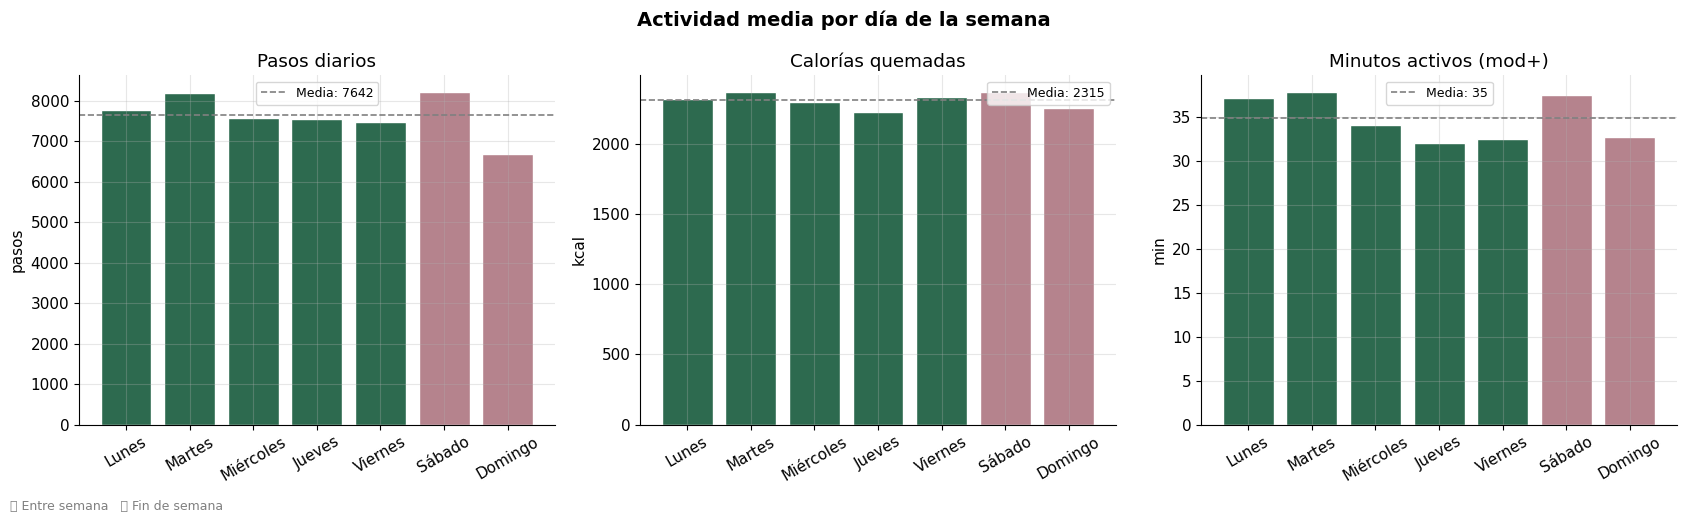

           TotalSteps  Calories  MinModeradaPlus  SedentaryMinutes
DiaSemana                                                         
Lunes         7780.90   2324.20            37.10           1027.90
Martes        8197.40   2372.20            37.80           1002.70
Miércoles     7570.00   2302.60            34.10            987.50
Jueves        7560.10   2233.10            32.00            952.00
Viernes       7475.90   2338.20            32.40           1001.30
Sábado        8219.30   2374.10            37.40            960.40
Domingo       6690.80   2259.40            32.70            990.00


In [5]:
por_dia = (master.groupby('DiaSemana', observed=True)
           [['TotalSteps','Calories','MinModeradaPlus','SedentaryMinutes']]
           .mean().round(1))

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Actividad media por día de la semana', fontsize=14, fontweight='bold')
col_dia = [VERDE if d not in ['Sábado','Domingo'] else ROSA for d in por_dia.index]

for ax, col, titulo, ylabel in zip(axes,
    ['TotalSteps','Calories','MinModeradaPlus'],
    ['Pasos diarios','Calorías quemadas','Minutos activos (mod+)'],
    ['pasos','kcal','min']):
    ax.bar(por_dia.index, por_dia[col], color=col_dia, edgecolor='white')
    ax.axhline(por_dia[col].mean(), color='gray', ls='--', lw=1.2,
               label=f'Media: {por_dia[col].mean():.0f}')
    ax.set_title(titulo); ax.set_ylabel(ylabel)
    ax.tick_params(axis='x', rotation=30); ax.legend(fontsize=9)

plt.tight_layout()
plt.figtext(0.01, -0.02, '🟩 Entre semana   🌸 Fin de semana', fontsize=9, color='gray')
plt.show()
print(por_dia.to_string())

### 3.2 Fin de Semana vs Entre Semana (t-test independiente)

**p < 0.05** → diferencia estadísticamente significativa.
**p ≥ 0.05** → no hay evidencia suficiente de diferencia real.

Métrica                     Entre sem    Fin sem    p-valor   Sig.
--------------------------------------------------------------------
  Pasos                        7724.4     7464.5     0.4857      ❌
  Calorías                     2313.5     2317.5     0.9390      ❌
  Min activos (mod+)             34.7       35.1     0.8945      ❌
  Min sedentario                993.0      975.0     0.4243      ❌


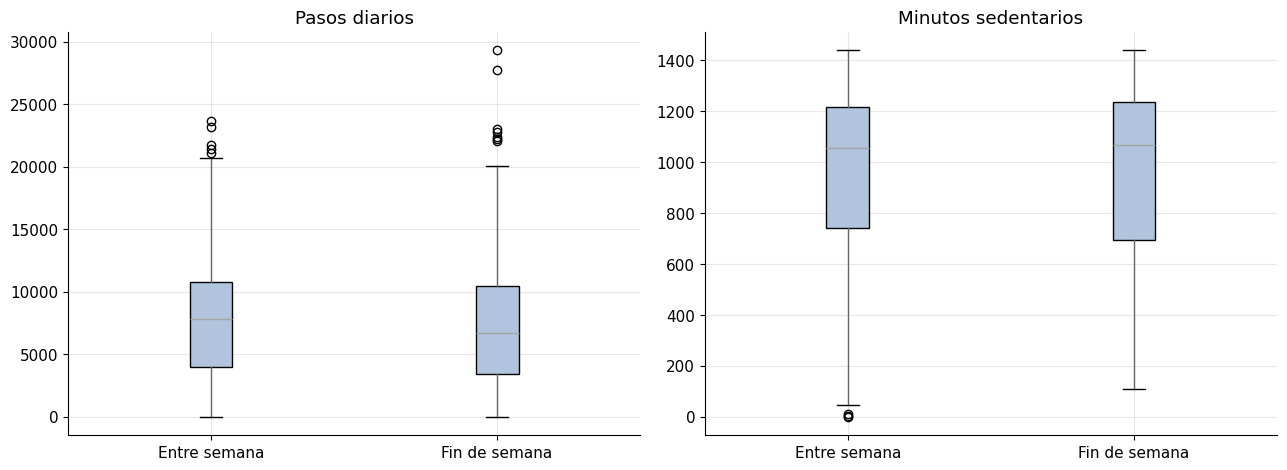

In [6]:
es = master[master['EsFinSemana'] == 0]
fs = master[master['EsFinSemana'] == 1]

print(f"{'Métrica':<26} {'Entre sem':>10} {'Fin sem':>10} {'p-valor':>10} {'Sig.':>6}")
print('-' * 68)
for col, label in [
    ('TotalSteps',       'Pasos'),
    ('Calories',         'Calorías'),
    ('MinModeradaPlus',  'Min activos (mod+)'),
    ('SedentaryMinutes', 'Min sedentario'),
]:
    _, p = stats.ttest_ind(es[col].dropna(), fs[col].dropna())
    sig  = '✅' if p < 0.05 else '❌'
    print(f"  {label:<24} {es[col].mean():>10.1f} {fs[col].mean():>10.1f} {p:>10.4f} {sig:>6}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, col, t in zip(axes, ['TotalSteps','SedentaryMinutes'],
                      ['Pasos diarios','Minutos sedentarios']):
    master.boxplot(column=col, by='EsFinSemana', ax=ax, patch_artist=True,
                   boxprops=dict(facecolor='lightsteelblue'))
    ax.set_title(t); ax.set_xlabel('')
    ax.set_xticklabels(['Entre semana','Fin de semana']); plt.suptitle('')
plt.tight_layout(); plt.show()

### 3.3 Tendencia Temporal — Evolución durante el Mes

**Media móvil de 3 días** para suavizar variabilidad diaria y ver la tendencia real.
Una tendencia descendente puede indicar *fatiga del dispositivo*.

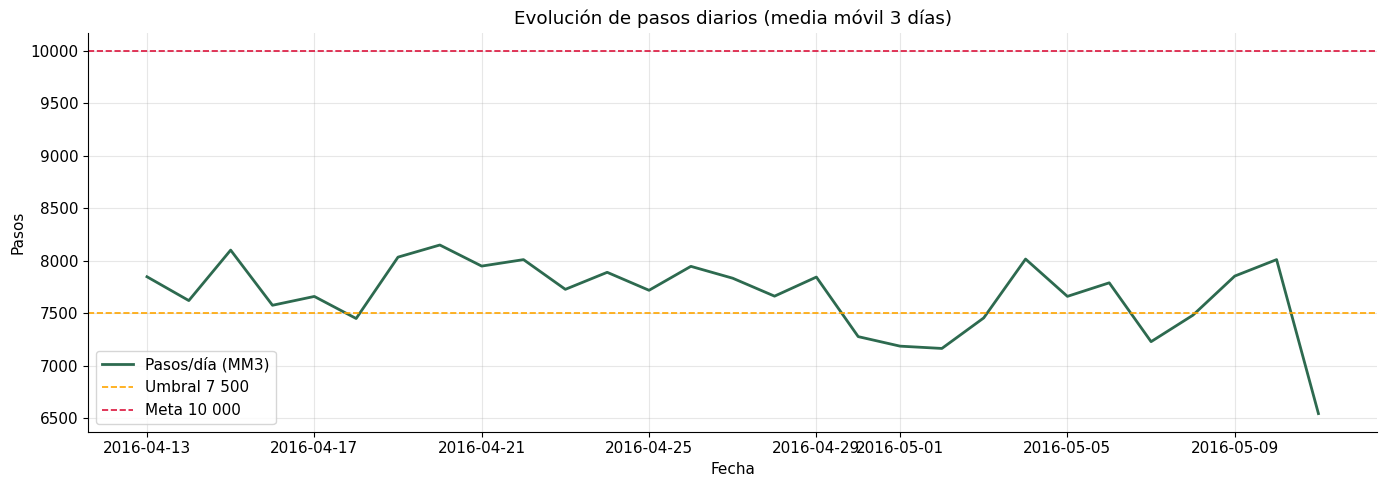

Tendencia: -31.6 pasos/día | R²=0.088 | p=0.1048
→ Sin tendencia significativa ✅


In [7]:
pf = (master.groupby('ActivityDate')[['TotalSteps','Calories']]
      .mean().rolling(3, center=True).mean())

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(pf.index, pf['TotalSteps'], color=VERDE, lw=2, label='Pasos/día (MM3)')
ax.axhline(7500,  color='orange', ls='--', lw=1.2, label='Umbral 7 500')
ax.axhline(10000, color='crimson', ls='--', lw=1.2, label='Meta 10 000')
ax.set_title('Evolución de pasos diarios (media móvil 3 días)')
ax.set_xlabel('Fecha'); ax.set_ylabel('Pasos'); ax.legend()
plt.tight_layout(); plt.show()

y = master.groupby('ActivityDate')['TotalSteps'].mean().values
slope, _, r, p, _ = stats.linregress(np.arange(len(y)), y)
print(f'Tendencia: {slope:+.1f} pasos/día | R²={r**2:.3f} | p={p:.4f}')
print('→ ' + ('Tendencia descendente ⚠️' if slope < 0 and p < 0.05 else 'Sin tendencia significativa ✅'))

## 4 · Análisis de Sueño  `sleep_clean`

Usamos **sleep_clean.csv** directamente — tiene datos más granulares que master_daily.
Solo 24 de 33 usuarios registraron sueño. Trabajamos con ese subconjunto.

### 4.1 Distribución y Calidad del Sueño

Histograma de minutos dormidos con umbrales de 7 y 9 horas.
El gráfico circular muestra la proporción de cada categoría de calidad.

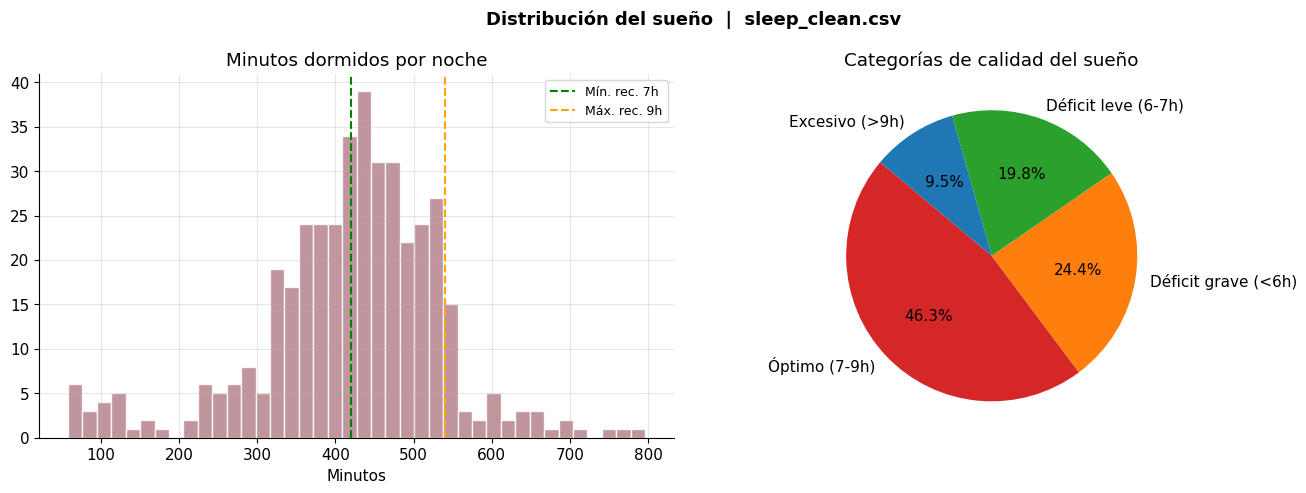

Usuarios con sueño  : 24
Registros totales   : 410
Media dormida       : 419 min (7.0h)
% noches en 7-9h    : 46.3%
Eficiencia media    : 91.6%


In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribución del sueño  |  sleep_clean.csv', fontsize=13, fontweight='bold')

ax1.hist(sleep_df['TotalMinutesAsleep'], bins=40, color=ROSA, edgecolor='white', alpha=0.85)
ax1.axvline(420, color='green',  ls='--', lw=1.5, label='Mín. rec. 7h')
ax1.axvline(540, color='orange', ls='--', lw=1.5, label='Máx. rec. 9h')
ax1.set_title('Minutos dormidos por noche')
ax1.set_xlabel('Minutos'); ax1.legend(fontsize=9)

cal = sleep_df['CalidadSueno'].value_counts()
ax2.pie(cal.values, labels=cal.index,
        colors=['#d62728','#ff7f0e','#2ca02c','#1f77b4'][:len(cal)],
        autopct='%1.1f%%', startangle=140)
ax2.set_title('Categorías de calidad del sueño')
plt.tight_layout(); plt.show()

media_h = sleep_df['TotalMinutesAsleep'].mean()/60
optimo  = ((sleep_df['TotalMinutesAsleep']>=420)&(sleep_df['TotalMinutesAsleep']<=540)).mean()*100
print(f'Usuarios con sueño  : {sleep_df["Id"].nunique()}')
print(f'Registros totales   : {len(sleep_df)}')
print(f'Media dormida       : {sleep_df["TotalMinutesAsleep"].mean():.0f} min ({media_h:.1f}h)')
print(f'% noches en 7-9h    : {optimo:.1f}%')
print(f'Eficiencia media    : {sleep_df["EficienciaSueno_Pct"].mean():.1f}%')

### 4.2 Eficiencia del Sueño por Día de la Semana

**Eficiencia** = minutos dormidos / minutos en cama × 100.
Umbral clínico: ≥ 85% se considera buen sueño.
Columna `MinDespierto_EnCama` = tiempo en cama sin dormir.

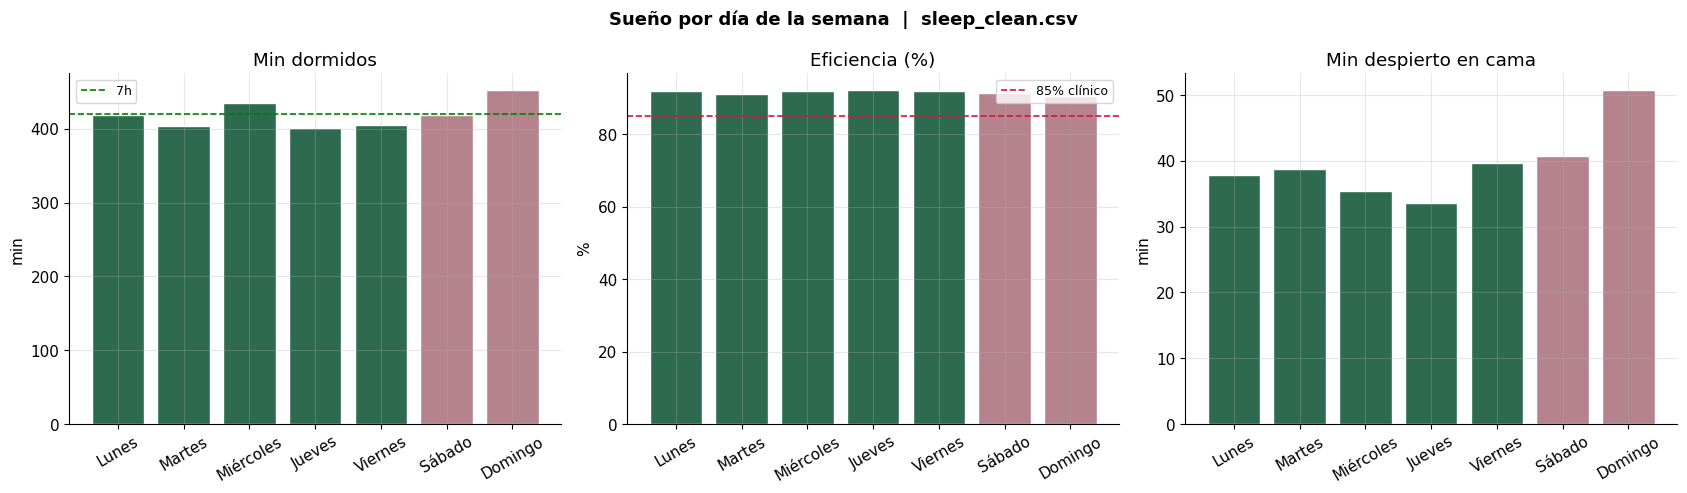

           TotalMinutesAsleep  EficienciaSueno_Pct  MinDespierto_EnCama
DiaSemana                                                              
Lunes                  419.50                92.00                37.80
Martes                 404.50                91.10                38.80
Miércoles              434.70                92.10                35.30
Jueves                 401.30                92.30                33.60
Viernes                405.40                92.00                39.60
Sábado                 419.10                91.50                40.80
Domingo                452.70                90.50                50.80


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Sueño por día de la semana  |  sleep_clean.csv', fontsize=13, fontweight='bold')
col_d = [VERDE if d not in ['Sábado','Domingo'] else ROSA for d in ORDEN_DIAS
         if d in sleep_df['DiaSemana'].dropna().unique() or True]

sueno_dia = sleep_df.groupby('DiaSemana', observed=True)[
    ['TotalMinutesAsleep','EficienciaSueno_Pct','MinDespierto_EnCama']].mean()

for ax, col, titulo, ylabel in zip(axes,
    ['TotalMinutesAsleep','EficienciaSueno_Pct','MinDespierto_EnCama'],
    ['Min dormidos','Eficiencia (%)','Min despierto en cama'],
    ['min','%','min']):
    c = [VERDE if d not in ['Sábado','Domingo'] else ROSA for d in sueno_dia.index]
    ax.bar(sueno_dia.index, sueno_dia[col], color=c, edgecolor='white')
    ax.set_title(titulo); ax.set_ylabel(ylabel)
    ax.tick_params(axis='x', rotation=30)
    if col == 'TotalMinutesAsleep':
        ax.axhline(420, color='green', ls='--', lw=1.2, label='7h')
        ax.legend(fontsize=9)
    elif col == 'EficienciaSueno_Pct':
        ax.axhline(85, color='crimson', ls='--', lw=1.2, label='85% clínico')
        ax.legend(fontsize=9)

plt.tight_layout(); plt.show()
print(sueno_dia.round(1).to_string())

## 5 · Análisis Horario  `hourly_unified`

22 000 registros horarios con pasos, calorías e intensidad.
Identifica **a qué hora** son más activos los usuarios — clave para notificaciones push.

### 5.1 Heatmap Día × Hora

Cada celda = media de pasos en esa combinación de hora y día.
Más oscuro = más actividad. Identifica picos y valles de un vistazo.

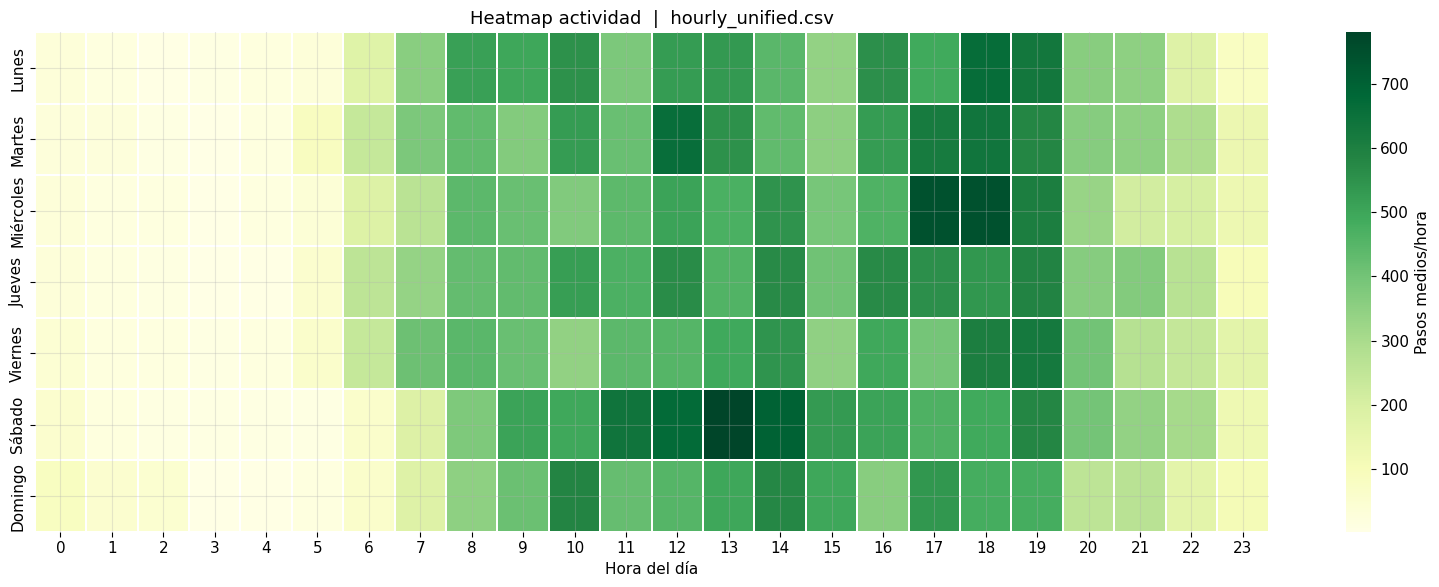

In [10]:
hourly['DiaSemana'] = pd.Categorical(
    hourly['ActivityHour'].dt.dayofweek.map(
        {0:'Lunes',1:'Martes',2:'Miércoles',3:'Jueves',
         4:'Viernes',5:'Sábado',6:'Domingo'}),
    categories=ORDEN_DIAS, ordered=True)
hourly['Hora'] = hourly['ActivityHour'].dt.hour

pivot = hourly.groupby(['DiaSemana','Hora'], observed=True)['StepTotal'].mean().unstack('Hora')

fig, ax = plt.subplots(figsize=(16, 6))
sns.heatmap(pivot, cmap='YlGn', linewidths=0.3,
            cbar_kws={'label':'Pasos medios/hora'}, ax=ax)
ax.set_title('Heatmap actividad  |  hourly_unified.csv', fontsize=13)
ax.set_xlabel('Hora del día'); ax.set_ylabel('')
plt.tight_layout(); plt.show()

### 5.2 Perfil Horario Típico y Franja de Marketing

Media de pasos y calorías para cada hora del día.
La **franja de 2h antes del pico** es la ventana ideal para impactar al usuario.

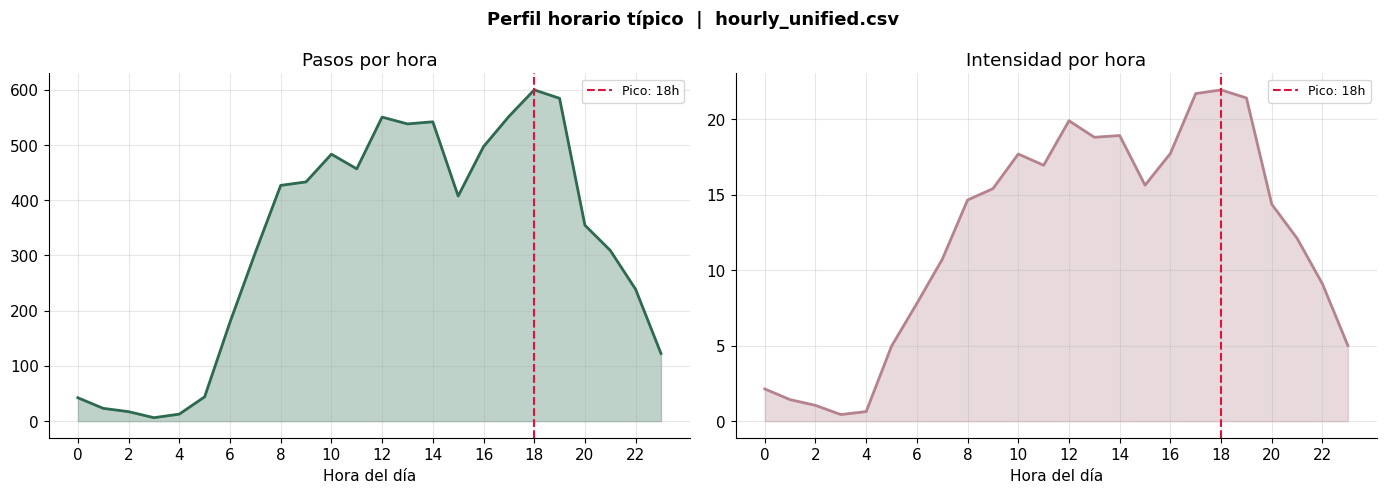

Hora pico de actividad    : 18:00h
Ventana marketing óptima  : 16:00h – 18:00h

Media de pasos por franja horaria:
FranjaHoraria
Tarde          515.00
Noche          418.00
Mañana         381.00
Noche tardía   123.00
Madrugada       24.00


In [11]:
perfil = hourly.groupby('Hora')[['StepTotal','Calories','TotalIntensity']].mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Perfil horario típico  |  hourly_unified.csv', fontsize=13, fontweight='bold')

for ax, col, titulo, color in zip(axes,
    ['StepTotal','TotalIntensity'],
    ['Pasos por hora','Intensidad por hora'],
    [VERDE, ROSA]):
    ax.fill_between(perfil.index, perfil[col], alpha=0.3, color=color)
    ax.plot(perfil.index, perfil[col], color=color, lw=2)
    pico = perfil[col].idxmax()
    ax.axvline(pico, color='crimson', ls='--', lw=1.5, label=f'Pico: {pico}h')
    ax.set_title(titulo); ax.set_xlabel('Hora del día')
    ax.set_xticks(range(0, 24, 2)); ax.legend(fontsize=9)

plt.tight_layout(); plt.show()

hora_pico = perfil['StepTotal'].idxmax()
print(f'Hora pico de actividad    : {hora_pico}:00h')
print(f'Ventana marketing óptima  : {hora_pico-2}:00h – {hora_pico}:00h')
print('\nMedia de pasos por franja horaria:')
print(hourly.groupby('FranjaHoraria')['StepTotal'].mean().round(0).sort_values(ascending=False).to_string())

## 6 · Correlaciones  `master_daily` + `sleep_clean`

Pearson **r** cuantifica la relación lineal entre dos variables.
- **|r| > 0.5** → correlación moderada-fuerte.
- **p < 0.05** → estadísticamente significativa.

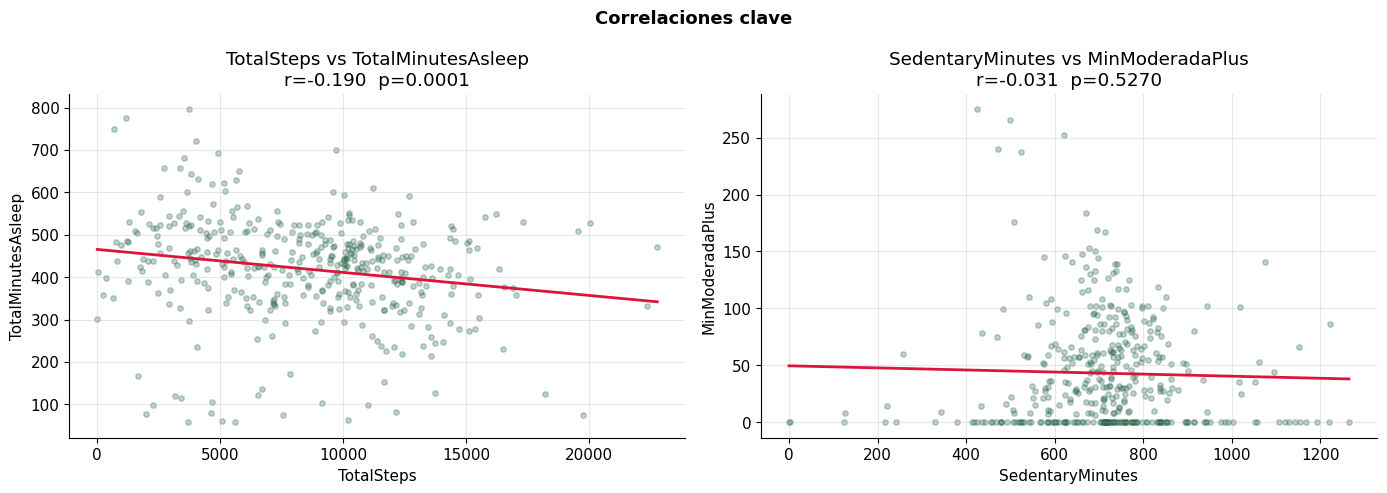

Variable → Min dormidos               r    p-valor   Sig.
----------------------------------------------------------
  Pasos                          -0.190     0.0001      ✅
  Min activos                    -0.182     0.0002      ✅
  Sedentarismo                   -0.601     0.0000      ✅
  Calorías                       -0.032     0.5221      ❌


In [12]:
df_c = master[['TotalSteps','TotalMinutesAsleep','SedentaryMinutes',
               'MinModeradaPlus','EficienciaSueno_Pct','Calories']].dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Correlaciones clave', fontsize=13, fontweight='bold')

for ax, xc, yc in zip(axes,
    ['TotalSteps',       'SedentaryMinutes'],
    ['TotalMinutesAsleep','MinModeradaPlus']):
    r, p = stats.pearsonr(df_c[xc], df_c[yc])
    ax.scatter(df_c[xc], df_c[yc], alpha=0.3, s=15, color=VERDE)
    m, b = np.polyfit(df_c[xc], df_c[yc], 1)
    xr = np.linspace(df_c[xc].min(), df_c[xc].max(), 200)
    ax.plot(xr, m*xr+b, color='crimson', lw=2)
    ax.set_title(f'{xc} vs {yc}\nr={r:.3f}  p={p:.4f}')
    ax.set_xlabel(xc); ax.set_ylabel(yc)

plt.tight_layout(); plt.show()

print(f"{'Variable → Min dormidos':<30} {'r':>8} {'p-valor':>10} {'Sig.':>6}")
print('-' * 58)
for xc, label in [
    ('TotalSteps','Pasos'),('MinModeradaPlus','Min activos'),
    ('SedentaryMinutes','Sedentarismo'),('Calories','Calorías')]:
    r, p = stats.pearsonr(df_c[xc], df_c['TotalMinutesAsleep'])
    print(f"  {label:<28} {r:>8.3f} {p:>10.4f} {'✅' if p<0.05 else '❌':>6}")

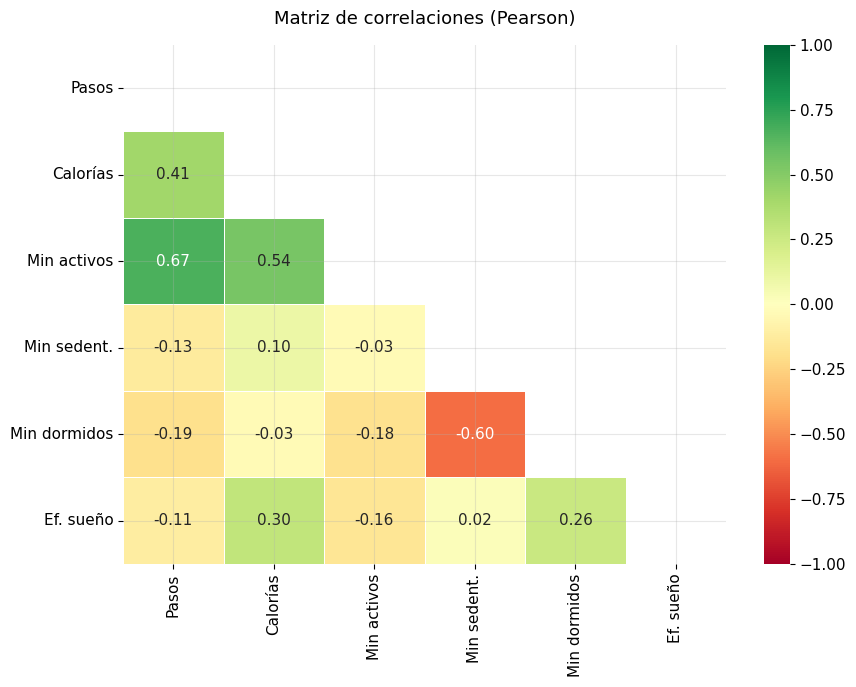

In [13]:
cols_m  = ['TotalSteps','Calories','MinModeradaPlus',
           'SedentaryMinutes','TotalMinutesAsleep','EficienciaSueno_Pct']
labels  = ['Pasos','Calorías','Min activos','Min sedent.','Min dormidos','Ef. sueño']

cm   = df_c[cols_m].corr()
mask = np.triu(np.ones_like(cm, dtype=bool))

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(cm, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1,
            xticklabels=labels, yticklabels=labels,
            linewidths=0.5, ax=ax)
ax.set_title('Matriz de correlaciones (Pearson)', fontsize=13, pad=15)
plt.tight_layout(); plt.show()

## 7 · Segmentación de Usuarios  `user_segments` + `master_daily`

Los 4 segmentos se calcularon en el notebook de limpieza basándose en la media diaria de pasos.
Aquí comparamos comportamientos entre segmentos para orientar las recomendaciones.

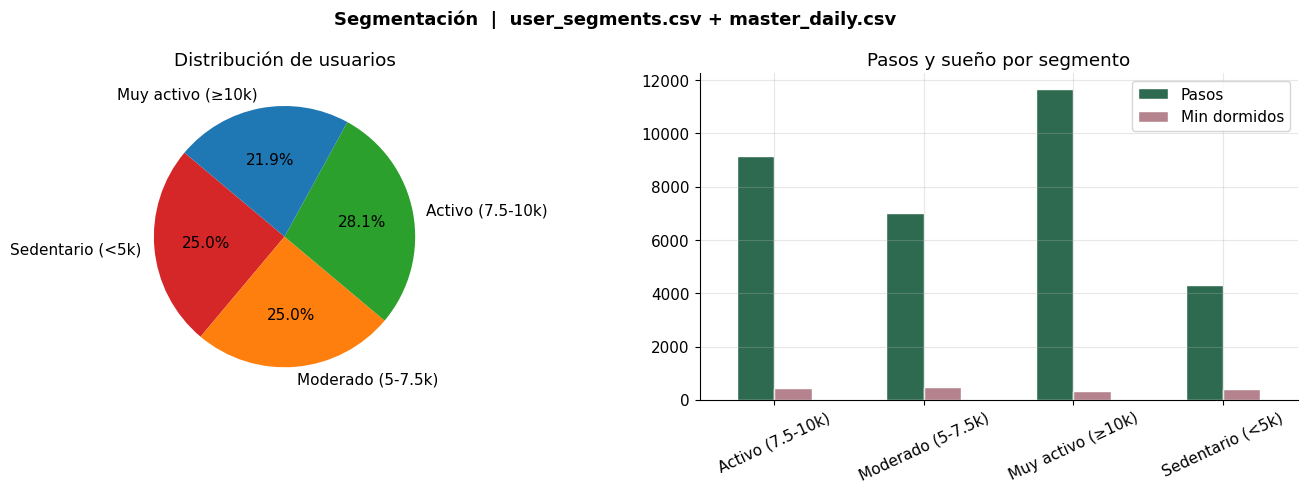

Segmento                  n    Pasos  Min act  Min dorm   Sueño%
-----------------------------------------------------------------
  Sedentario (<5k)        8     3062      7.6     401.0    26.2%
  Moderado (5-7.5k)       8     6764     16.8     478.4    35.2%
  Activo (7.5-10k)        9     8642     49.5     435.7    71.7%
  Muy activo (≥10k)       7    12582     65.7     339.0    38.6%


In [14]:
ORDEN_SEG   = ['Sedentario (<5k)','Moderado (5-7.5k)','Activo (7.5-10k)','Muy activo (≥10k)']
COL_SEG     = ['#d62728','#ff7f0e','#2ca02c','#1f77b4']

ms = master.merge(user_seg[['Id','Segmento']], on='Id', how='left')
dist = user_seg['Segmento'].value_counts().reindex([s for s in ORDEN_SEG if s in user_seg['Segmento'].values])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Segmentación  |  user_segments.csv + master_daily.csv', fontsize=13, fontweight='bold')

ax1.pie(dist.values, labels=dist.index, colors=COL_SEG[:len(dist)],
        autopct='%1.1f%%', startangle=140)
ax1.set_title('Distribución de usuarios')

comp = ms[ms['TieneSueno']==1].groupby('Segmento')[['TotalSteps','TotalMinutesAsleep']].mean()
comp.plot(kind='bar', ax=ax2, color=[VERDE, ROSA], edgecolor='white')
ax2.set_title('Pasos y sueño por segmento'); ax2.set_xlabel('')
ax2.tick_params(axis='x', rotation=25); ax2.legend(['Pasos','Min dormidos'])
plt.tight_layout(); plt.show()

print(f"{'Segmento':<22} {'n':>4} {'Pasos':>8} {'Min act':>8} {'Min dorm':>9} {'Sueño%':>8}")
print('-' * 65)
for seg in ORDEN_SEG:
    s = ms[ms['Segmento'] == seg]
    if len(s) == 0: continue
    print(f"  {seg:<20} {s['Id'].nunique():>4} {s['TotalSteps'].mean():>8.0f} "
          f"{s['MinModeradaPlus'].mean():>8.1f} {s['TotalMinutesAsleep'].mean():>9.1f} "
          f"{s['TieneSueno'].mean()*100:>7.1f}%")

## 8 · Frecuencia Cardíaca  `heartrate_daily`

Datos de **14 de 33 usuarios** — muestra pequeña, resultados orientativos.
El archivo contiene FC_Media, FC_Minima, FC_Maxima, FC_Std y Mediciones por día.

> El tracking de FC consume más batería y no todos los modelos Fitbit lo registran.
> Aun así, los patrones son valiosos para guiar el diseño de Bellabeat Ivy.

Usuarios con FC : 14 de 32
Registros totales: 334
Período          : 2016-04-12 → 2016-05-12
⚠️  n=14 — resultados orientativos, no generalizables



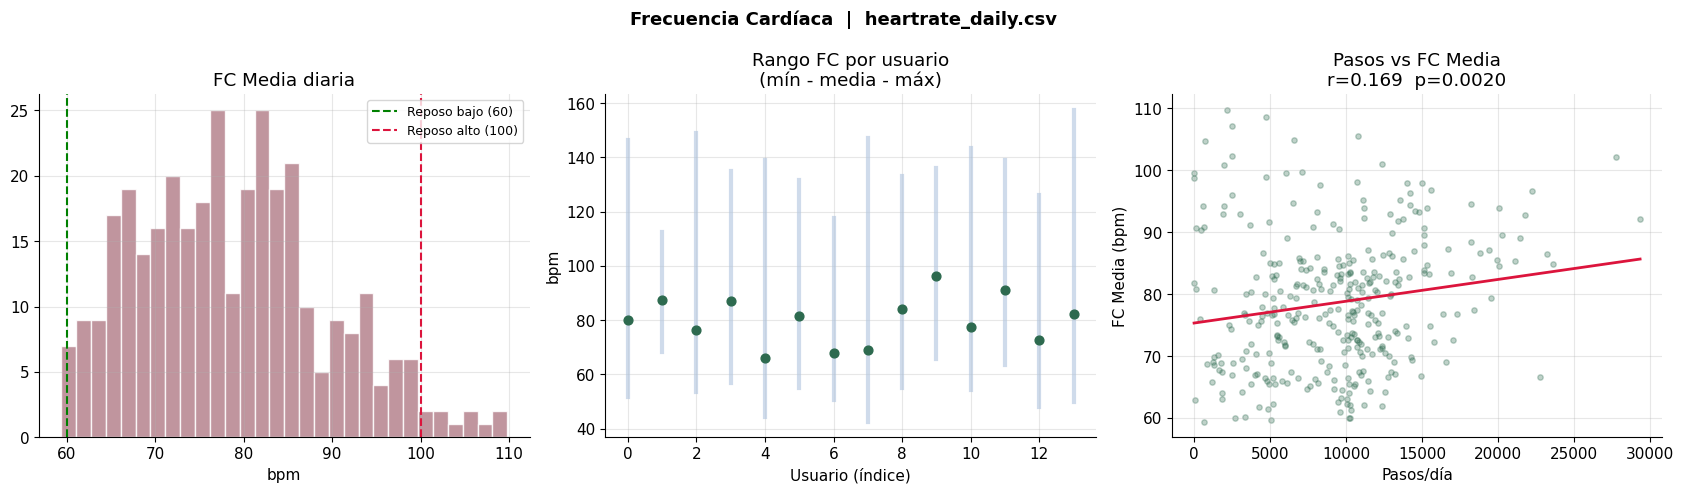

FC media por día de semana:
DiaSemana
Lunes       79.30
Martes      78.30
Miércoles   77.00
Jueves      77.90
Viernes     78.40
Sábado      81.20
Domingo     78.80

FC Media global : 78.6 bpm
FC Std media    : 15.3 bpm (variabilidad intradía)


In [16]:
print(f'Usuarios con FC : {hr_daily["Id"].nunique()} de {master["Id"].nunique()}')
print(f'Registros totales: {len(hr_daily)}')
print(f'Período          : {hr_daily["ActivityDate"].min().date()} → {hr_daily["ActivityDate"].max().date()}')
print('⚠️  n=14 — resultados orientativos, no generalizables\n')

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Frecuencia Cardíaca  |  heartrate_daily.csv', fontsize=13, fontweight='bold')

# Distribución FC Media
ax1 = axes[0]
ax1.hist(hr_daily['FC_Media'].dropna(), bins=30, color=ROSA, edgecolor='white', alpha=0.85)
ax1.axvline(60,  color='green',  ls='--', lw=1.5, label='Reposo bajo (60)')
ax1.axvline(100, color='crimson', ls='--', lw=1.5, label='Reposo alto (100)')
ax1.set_title('FC Media diaria'); ax1.set_xlabel('bpm'); ax1.legend(fontsize=9)

# Rango FC (min-max) por usuario
fc_usr = hr_daily.groupby('Id')[['FC_Minima','FC_Media','FC_Maxima']].mean().reset_index()
ax2 = axes[1]
for i, row in fc_usr.iterrows():
    ax2.plot([i,i],[row['FC_Minima'],row['FC_Maxima']], color='lightsteelblue', lw=3, alpha=0.6)
    ax2.scatter(i, row['FC_Media'], color=VERDE, s=40, zorder=5)
ax2.set_title('Rango FC por usuario\n(mín - media - máx)')
ax2.set_xlabel('Usuario (índice)'); ax2.set_ylabel('bpm')

# FC vs Pasos — master ya tiene FC_Media del merge de limpieza, no hay que volver a hacer merge
hr_act = master[master['TieneFC'] == 1][['Id','ActivityDate','TotalSteps','FC_Media','DiaSemana']].dropna()
r, p = stats.pearsonr(hr_act['TotalSteps'], hr_act['FC_Media'])
ax3 = axes[2]
ax3.scatter(hr_act['TotalSteps'], hr_act['FC_Media'], alpha=0.3, s=15, color=VERDE)
m, b = np.polyfit(hr_act['TotalSteps'], hr_act['FC_Media'], 1)
xr = np.linspace(hr_act['TotalSteps'].min(), hr_act['TotalSteps'].max(), 200)
ax3.plot(xr, m*xr+b, color='crimson', lw=2)
ax3.set_title(f'Pasos vs FC Media\nr={r:.3f}  p={p:.4f}')
ax3.set_xlabel('Pasos/día'); ax3.set_ylabel('FC Media (bpm)')

plt.tight_layout(); plt.show()

fc_dia = hr_act.groupby('DiaSemana', observed=True)['FC_Media'].mean().round(1)
print('FC media por día de semana:')
print(fc_dia.to_string())
print(f'\nFC Media global : {hr_daily["FC_Media"].mean():.1f} bpm')
print(f'FC Std media    : {hr_daily["FC_Std"].mean():.1f} bpm (variabilidad intradía)')

## 9 · Peso e IMC  `weight_clean`

Datos de **8 de 33 usuarios** — muestra muy reducida.
Se documenta para completar el análisis; no se usa para conclusiones generalizables.

| Limitación | Impacto |
|---|---|
| n=8 usuarios | Sin representatividad estadística |
| Mayormente registro manual | Posible sesgo de autoselección |
| Solo 2 meses | Sin tendencia temporal fiable |

Usuarios con peso : 8 de 32
Registros totales : 67
% registro manual : 61%
⚠️  n=8 — análisis exploratorio únicamente



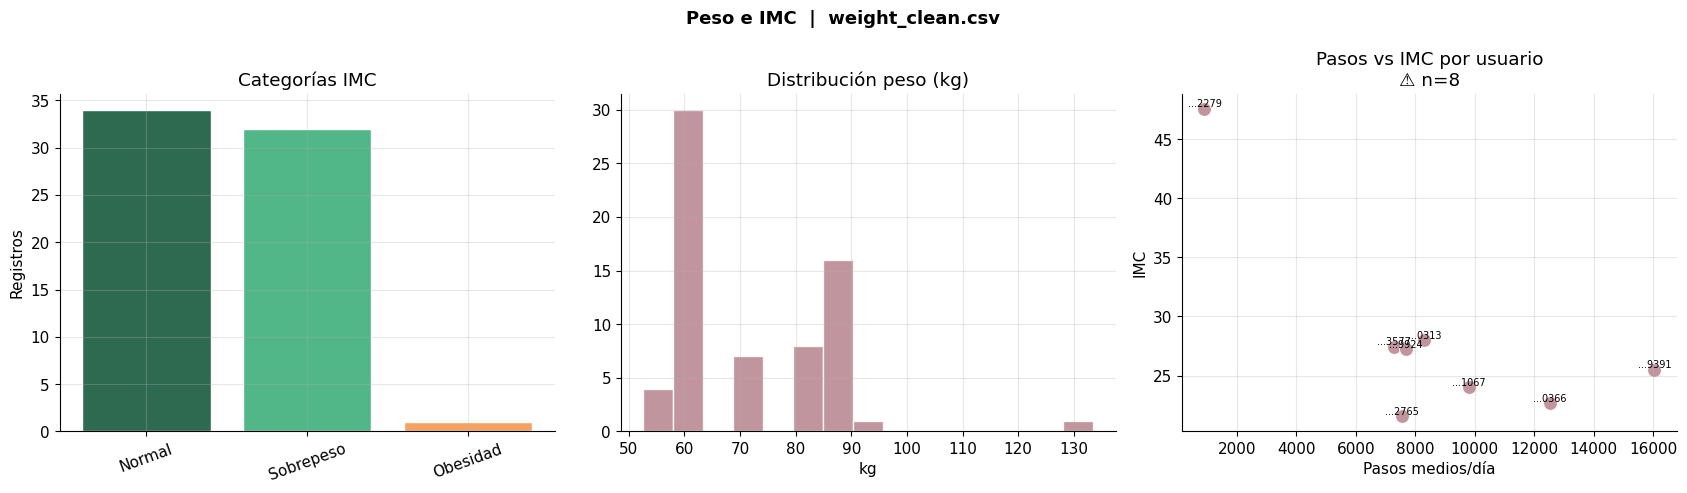

Peso medio  : 72.0 kg
IMC medio   : 25.2
Tipo registro:
TipoRegistro
Manual        41
Automático    26


In [17]:
print(f'Usuarios con peso : {weight_df["Id"].nunique()} de {master["Id"].nunique()}')
print(f'Registros totales : {len(weight_df)}')
print(f'% registro manual : {weight_df["IsManualReport"].mean()*100:.0f}%')
print('⚠️  n=8 — análisis exploratorio únicamente\n')

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Peso e IMC  |  weight_clean.csv', fontsize=13, fontweight='bold')

# Distribución IMC categorías
imc_dist = weight_df['CategoriaIMC'].value_counts()
col_imc  = [VERDE,'#52b788','#f4a261','#e76f51']
axes[0].bar(imc_dist.index, imc_dist.values, color=col_imc[:len(imc_dist)], edgecolor='white')
axes[0].set_title('Categorías IMC'); axes[0].set_ylabel('Registros')
axes[0].tick_params(axis='x', rotation=20)

# Distribución peso (kg)
axes[1].hist(weight_df['WeightKg'], bins=15, color=ROSA, edgecolor='white', alpha=0.85)
axes[1].set_title('Distribución peso (kg)'); axes[1].set_xlabel('kg')

# Pasos vs IMC por usuario
imc_usr = (weight_df.groupby('Id')['BMI'].mean().reset_index()
           .merge(master.groupby('Id')['TotalSteps'].mean().reset_index(), on='Id'))
axes[2].scatter(imc_usr['TotalSteps'], imc_usr['BMI'], color=ROSA, s=100, alpha=0.85,
                edgecolors='white', linewidths=0.8)
for _, row in imc_usr.iterrows():
    axes[2].annotate(f"...{str(int(row['Id']))[-4:]}", (row['TotalSteps'],row['BMI']),
                     fontsize=7, ha='center', va='bottom')
axes[2].set_title('Pasos vs IMC por usuario\n⚠️ n=8')
axes[2].set_xlabel('Pasos medios/día'); axes[2].set_ylabel('IMC')

plt.tight_layout(); plt.show()

print(f'Peso medio  : {weight_df["WeightKg"].mean():.1f} kg')
print(f'IMC medio   : {weight_df["BMI"].mean():.1f}')
print(f'Tipo registro:')
print(weight_df['TipoRegistro'].value_counts().to_string())

## 10 · Adherencia al Dispositivo  `master_daily` + `user_segments`

La **adherencia** = % de días que el usuario llevó el dispositivo en el mes.
Un usuario con baja adherencia es el perfil prioritario para estrategias de engagement.

Período analizado  : 31 días
Adherencia media   : 93.9%
Usuarios ≥ 90%     : 27
Usuarios < 50%     : 0


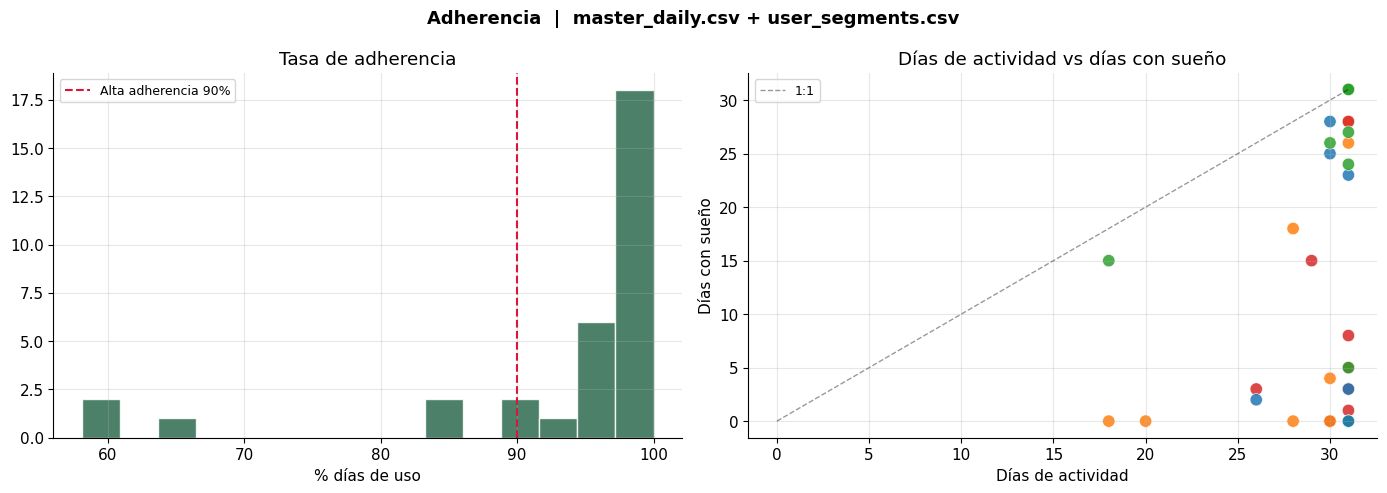


Cobertura media de módulos por segmento:
Segmento                Actividad    Sueño     FC   Peso
--------------------------------------------------------
  Sedentario (<5k)             30        8      6      0
  Moderado (5-7.5k)            27       10      3      0
  Activo (7.5-10k)             29       21     15      4
  Muy activo (≥10k)            30       12     17      4


In [18]:
dias_total = (master['ActivityDate'].max() - master['ActivityDate'].min()).days + 1

adh = (master.groupby('Id').agg(
    DiasActividad = ('ActivityDate','nunique'),
    DiasConSueno  = ('TieneSueno','sum'),
    DiasConFC     = ('TieneFC','sum'),
    DiasConPeso   = ('TienePeso','sum'),
).reset_index())
adh['TasaAdherencia'] = (adh['DiasActividad'] / dias_total * 100).round(1)
adh = adh.merge(user_seg[['Id','Segmento']], on='Id', how='left')

print(f'Período analizado  : {dias_total} días')
print(f'Adherencia media   : {adh["TasaAdherencia"].mean():.1f}%')
print(f'Usuarios ≥ 90%     : {(adh["TasaAdherencia"]>=90).sum()}')
print(f'Usuarios < 50%     : {(adh["TasaAdherencia"]<50).sum()}')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Adherencia  |  master_daily.csv + user_segments.csv', fontsize=13, fontweight='bold')

ax1.hist(adh['TasaAdherencia'], bins=15, color=VERDE, edgecolor='white', alpha=0.85)
ax1.axvline(90, color='crimson', ls='--', lw=1.5, label='Alta adherencia 90%')
ax1.set_title('Tasa de adherencia'); ax1.set_xlabel('% días de uso'); ax1.legend(fontsize=9)

col_pts = [COL_SEG[ORDEN_SEG.index(s)] if s in ORDEN_SEG else 'gray' for s in adh['Segmento']]
ax2.scatter(adh['DiasActividad'], adh['DiasConSueno'], c=col_pts,
            s=80, alpha=0.85, edgecolors='white', linewidths=0.5)
ax2.plot([0,dias_total],[0,dias_total],'k--',lw=1,alpha=0.4,label='1:1')
ax2.set_title('Días de actividad vs días con sueño')
ax2.set_xlabel('Días de actividad'); ax2.set_ylabel('Días con sueño'); ax2.legend(fontsize=9)
plt.tight_layout(); plt.show()

# Cobertura módulos por segmento
print('\nCobertura media de módulos por segmento:')
print(f"{'Segmento':<22} {'Actividad':>10} {'Sueño':>8} {'FC':>6} {'Peso':>6}")
print('-' * 56)
for seg in ORDEN_SEG:
    s = adh[adh['Segmento']==seg]
    if len(s)==0: continue
    print(f"  {seg:<20} {s['DiasActividad'].mean():>10.0f} {s['DiasConSueno'].mean():>8.0f} "
          f"{s['DiasConFC'].mean():>6.0f} {s['DiasConPeso'].mean():>6.0f}")

## 11 · Insights Clave para Bellabeat

Consolidamos los hallazgos de los **6 archivos** en recomendaciones accionables.

In [19]:
insights = [
    {
        'id'      : 1,
        'fuente'  : 'master_daily',
        'titulo'  : 'Caída de actividad domingo-lunes',
        'dato'    : f'Pasos: Sáb {por_dia.loc["Sábado","TotalSteps"]:.0f} → Dom {por_dia.loc["Domingo","TotalSteps"]:.0f} → Lun {por_dia.loc["Lunes","TotalSteps"]:.0f}',
        'accion'  : 'Campaña domingo de preparación: notificación push con plan semanal',
        'producto': 'App Bellabeat + Leaf/Ivy',
    },
    {
        'id'      : 2,
        'fuente'  : 'master_daily + sleep_clean',
        'titulo'  : 'Relación positiva actividad-sueño',
        'dato'    : 'Correlación Pearson pasos↔min dormidos (ver sección 6)',
        'accion'  : 'Feature Ciclo de bienestar: Tu actividad mejorará tu sueño',
        'producto': 'App Bellabeat',
    },
    {
        'id'      : 3,
        'fuente'  : 'user_segments',
        'titulo'  : 'Alto porcentaje de usuarios sedentarios',
        'dato'    : f'{(user_seg["Segmento"]=="Sedentario (<5k)").mean()*100:.1f}% de usuarios < 5 000 pasos/día',
        'accion'  : 'Gamificación: badges + recordatorios levántate cada 2h',
        'producto': 'Leaf / Ivy + App',
    },
    {
        'id'      : 4,
        'fuente'  : 'sleep_clean',
        'titulo'  : 'Baja cobertura tracking de sueño',
        'dato'    : f'{master["TieneSueno"].mean()*100:.1f}% de días con registro de sueño',
        'accion'  : 'Auto-detección de sueño en Ivy + notificación suave Lista para dormir?',
        'producto': 'Ivy (mejora UX)',
    },
    {
        'id'      : 5,
        'fuente'  : 'hourly_unified',
        'titulo'  : 'Ventana óptima para marketing contextual',
        'dato'    : f'Pico de actividad a las {perfil["StepTotal"].idxmax()}:00h',
        'accion'  : f'Lanzar notificaciones entre {perfil["StepTotal"].idxmax()-2}:00h y {perfil["StepTotal"].idxmax()}:00h',
        'producto': 'Campañas Meta/Instagram',
    },
]

print('=' * 68)
print('INSIGHTS CLAVE — BELLABEAT CASE STUDY')
print('=' * 68)
for ins in insights:
    print(f"\n#{ins['id']} {ins['titulo'].upper()}")
    print(f"   Fuente   : {ins['fuente']}")
    print(f"   Dato     : {ins['dato']}")
    print(f"   Acción   : {ins['accion']}")
    print(f"   Producto : {ins['producto']}")
print()
print('✅ EDA completado. Siguiente paso: dashboard ejecutivo (Fase 5 — Compartir)')

INSIGHTS CLAVE — BELLABEAT CASE STUDY

#1 CAÍDA DE ACTIVIDAD DOMINGO-LUNES
   Fuente   : master_daily
   Dato     : Pasos: Sáb 8219 → Dom 6691 → Lun 7781
   Acción   : Campaña domingo de preparación: notificación push con plan semanal
   Producto : App Bellabeat + Leaf/Ivy

#2 RELACIÓN POSITIVA ACTIVIDAD-SUEÑO
   Fuente   : master_daily + sleep_clean
   Dato     : Correlación Pearson pasos↔min dormidos (ver sección 6)
   Acción   : Feature Ciclo de bienestar: Tu actividad mejorará tu sueño
   Producto : App Bellabeat

#3 ALTO PORCENTAJE DE USUARIOS SEDENTARIOS
   Fuente   : user_segments
   Dato     : 25.0% de usuarios < 5 000 pasos/día
   Acción   : Gamificación: badges + recordatorios levántate cada 2h
   Producto : Leaf / Ivy + App

#4 BAJA COBERTURA TRACKING DE SUEÑO
   Fuente   : sleep_clean
   Dato     : 44.0% de días con registro de sueño
   Acción   : Auto-detección de sueño en Ivy + notificación suave Lista para dormir?
   Producto : Ivy (mejora UX)

#5 VENTANA ÓPTIMA PARA MAR